# **Project Name**    - **Global Vaccination Coverage, Disease Dynamics, and Policy Analytics**


##### **Project Type**    - Exploratory Data Analysis (EDA)
##### **Domain**          - Public Health, Epidemiology, and Healthcare Analytics
##### **Contribution**    - Individual / Team


# **Project Summary -**

### **Executive Summary**

Immunization is universally acknowledged as one of modern medicine's most cost-effective public health interventions, saving millions of lives annually from preventable diseases such as measles, polio, diphtheria, tetanus, hepatitis B, and tuberculosis. However, significant disparities in vaccine coverage persist across World Health Organization (WHO) regions, driven by supply chain bottlenecks, political instability, geographic isolation, and socioeconomic inequalities.

This project undertakes an in-depth Exploratory Data Analysis (EDA) of global vaccination ecosystems using multi-source surveillance data comprising over 700,000 observations across five distinct datasets: (1) Vaccination Coverage, (2) Disease Incidence Rates, (3) Reported Disease Cases, (4) National Vaccine Introductions, and (5) Immunization Schedules. The primary objective is to evaluate multi-decade trends in vaccine uptake, quantify dose dropout rates (e.g., DTP1 to DTP3), measure the epidemiological impact of national vaccine rollouts on disease reduction, and assess global progress toward international health milestones, including the WHO Immunization Agenda 2030 (target of 95% measles coverage).

Through data wrangling, normalization, statistical correlation, and geospatial aggregation, this analysis answers critical public health questions: (a) How does vaccination coverage correlate with reduction in disease incidence? (b) Which regions exhibit the highest drop-off between primary and subsequent doses? (c) How do vaccine introductions alter disease incidence trajectories before and after implementation? (d) Which regions represent high-risk 'zero-dose' and under-immunized clusters requiring emergency resource allocation?

The analytical insights derived from this study directly inform resource distribution, cold-chain capacity investments, targeted outreach in sub-national geo-areas, and the strategic deployment of booster schedules, providing public health agencies, governments, and NGOs with an empirical foundation for data-driven disease eradication.

# **GitHub Link -**

[GitHub Repository Link](https://github.com/publichealth/vaccination-data-analytics)


# **Problem Statement**


### **Problem Statement**

Global public health organizations and ministries of health face persistent challenges in monitoring vaccine coverage, tracking dose completion, identifying geographic disparities, and controlling preventable disease outbreaks. Despite extensive routine immunization campaigns, millions of children in low- and middle-income nations remain 'zero-dose' or drop out before completing essential multi-dose regimens.

The goal of this project is to:
1. Clean, standardize, and integrate five disparate global health datasets across countries and time.
2. Analyze historical trends in coverage, drop-off rates, and disease reduction across WHO regions.
3. Evaluate the quantitative impact of vaccine rollouts on disease incidence before and after introduction.
4. Address all 29 public health questions and real-world scenario challenges specified by WHO guidelines.
5. Deliver an end-to-end analytical framework and database to support evidence-based policy formulation.

#### **Define Your Business Objective?**

### **Business Objectives**

- **Public Health Strategy**: Identify under-performing regions and antigens to prioritize high-impact interventions.
- **Dropout Reduction**: Quantify retention gaps between 1st dose and subsequent booster doses (DTP1 $\rightarrow$ DTP3, MCV1 $\rightarrow$ MCV2) to strengthen routine healthcare delivery.
- **Epidemiological Efficacy**: Measure the direct correlation between rising vaccination rates and declining disease burden.
- **Resource Allocation**: Pinpoint high-burden zero-dose cohorts to optimize vaccine supply chains and funding.
- **Milestone Tracking**: Monitor adherence to WHO 2030 targets (95% coverage for measles elimination).

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [17]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
print('Libraries successfully imported.')


Libraries successfully imported.


### Dataset Loading

In [19]:
# Load cleaned datasets
dim_country = pd.read_csv('cleaned_data/dim_country.csv')
dim_antigen = pd.read_csv('cleaned_data/dim_antigen.csv')
dim_disease = pd.read_csv('cleaned_data/dim_disease.csv')
fact_cov = pd.read_csv('cleaned_data/fact_coverage.csv')
fact_inc = pd.read_csv('cleaned_data/fact_incidence_rate.csv')
fact_cases = pd.read_csv('cleaned_data/fact_reported_cases.csv')
fact_intro = pd.read_csv('cleaned_data/fact_vaccine_intro.csv')
fact_sched = pd.read_csv('cleaned_data/fact_vaccine_schedule.csv')

print('All 8 cleaned dimension and fact datasets loaded successfully.')


All 8 cleaned dimension and fact datasets loaded successfully.


### Dataset First View

In [21]:
# First look at the primary datasets
print('--- Coverage Data ---')
display(fact_cov.head(3))
print('--- Incidence Rate Data ---')
display(fact_inc.head(3))
print('--- Reported Cases Data ---')
display(fact_cases.head(3))
print('--- Vaccine Introduction Data ---')
display(fact_intro.head(3))
print('--- Vaccine Schedule Data ---')
display(fact_sched.head(3))


--- Coverage Data ---
  CODE  YEAR ANTIGEN_CODE COVERAGE_CATEGORY  TARGET_NUMBER  DOSES  COVERAGE
0  ABW  2023          BCG             ADMIN            NaN    NaN       NaN
1  ABW  2023          BCG          OFFICIAL            NaN    NaN       NaN
2  ABW  2023      DIPHCV4             ADMIN         1044.0  945.0     90.52
--- Incidence Rate Data ---
  CODE  YEAR     DISEASE_CODE                     DENOMINATOR  INCIDENCE_RATE
0  ABW  2023              CRS          per 10,000 live births             0.0
1  ABW  2023       DIPHTHERIA  per 1,000,000 total population             0.0
2  ABW  2023  INVASIVE_MENING  per 1,000,000 total population             9.3
--- Reported Cases Data ---
  CODE  YEAR     DISEASE_CODE  CASES
0  ABW  2023              CRS    0.0
1  ABW  2023       DIPHTHERIA    0.0
2  ABW  2023  INVASIVE_MENING    1.0
--- Vaccine Introduction Data ---
  CODE  YEAR               VACCINE_DESCRIPTION INTRO
0  AFG  2023  aP (acellular pertussis) vaccine    No
1  AFG  2023      

### Dataset Rows & Columns count

In [23]:
# Dataset Rows and Columns count
shapes = {
    'dim_country': dim_country.shape,
    'dim_antigen': dim_antigen.shape,
    'dim_disease': dim_disease.shape,
    'fact_coverage': fact_cov.shape,
    'fact_incidence_rate': fact_inc.shape,
    'fact_reported_cases': fact_cases.shape,
    'fact_vaccine_intro': fact_intro.shape,
    'fact_vaccine_schedule': fact_sched.shape
}
for name, s in shapes.items():
    print(f'{name:<25}: {s[0]:>8,} rows, {s[1]:>2} columns')


dim_country              :      245 rows,  3 columns
dim_antigen              :      151 rows,  2 columns
dim_disease              :       13 rows,  2 columns
fact_coverage            :  399,858 rows,  7 columns
fact_incidence_rate      :   84,945 rows,  5 columns
fact_reported_cases      :   84,869 rows,  4 columns
fact_vaccine_intro       :  138,320 rows,  4 columns
fact_vaccine_schedule    :    8,052 rows,  9 columns


### Dataset Information

In [25]:
# Dataset Information
print('=== Coverage Info ===')
fact_cov.info()
print('\n=== Incidence Rate Info ===')
fact_inc.info()


=== Coverage Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399858 entries, 0 to 399857
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CODE               399858 non-null  object 
 1   YEAR               399858 non-null  int64  
 2   ANTIGEN_CODE       399858 non-null  object 
 3   COVERAGE_CATEGORY  399858 non-null  object 
 4   TARGET_NUMBER      79030 non-null   float64
 5   DOSES              79327 non-null   float64
 6   COVERAGE           230477 non-null  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 21.4+ MB

=== Incidence Rate Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84945 entries, 0 to 84944
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CODE            84945 non-null  object 
 1   YEAR            84945 non-null  int64  
 2   DISEASE_CODE    84945 non-null  object 
 3

#### Duplicate Values

In [27]:
# Duplicate values count
for name, df in [
    ('Coverage', fact_cov),
    ('Incidence', fact_inc),
    ('Cases', fact_cases),
    ('Intro', fact_intro),
    ('Schedule', fact_sched)
]:
    print(f'{name} duplicate rows: {df.duplicated().sum():,}')


Coverage duplicate rows: 0
Incidence duplicate rows: 0
Cases duplicate rows: 0
Intro duplicate rows: 0
Schedule duplicate rows: 0


#### Missing Values/Null Values

In [29]:
# Missing Values / Null Values Count
for name, df in [
    ('Coverage', fact_cov),
    ('Incidence Rate', fact_inc),
    ('Reported Cases', fact_cases),
    ('Vaccine Intro', fact_intro),
    ('Vaccine Schedule', fact_sched)
]:
    print(f'=== {name} Missing Values ===')
    print(df.isnull().sum())
    print('-'*40)


=== Coverage Missing Values ===
CODE                      0
YEAR                      0
ANTIGEN_CODE              0
COVERAGE_CATEGORY         0
TARGET_NUMBER        320828
DOSES                320531
COVERAGE             169381
dtype: int64
----------------------------------------
=== Incidence Rate Missing Values ===
CODE                  0
YEAR                  0
DISEASE_CODE          0
DENOMINATOR           0
INCIDENCE_RATE    23361
dtype: int64
----------------------------------------
=== Reported Cases Missing Values ===
CODE                0
YEAR                0
DISEASE_CODE        0
CASES           19399
dtype: int64
----------------------------------------
=== Vaccine Intro Missing Values ===
CODE                   0
YEAR                   0
VACCINE_DESCRIPTION    0
INTRO                  0
dtype: int64
----------------------------------------
=== Vaccine Schedule Missing Values ===
CODE                        0
YEAR                        0
ANTIGEN_CODE                0
SCHED

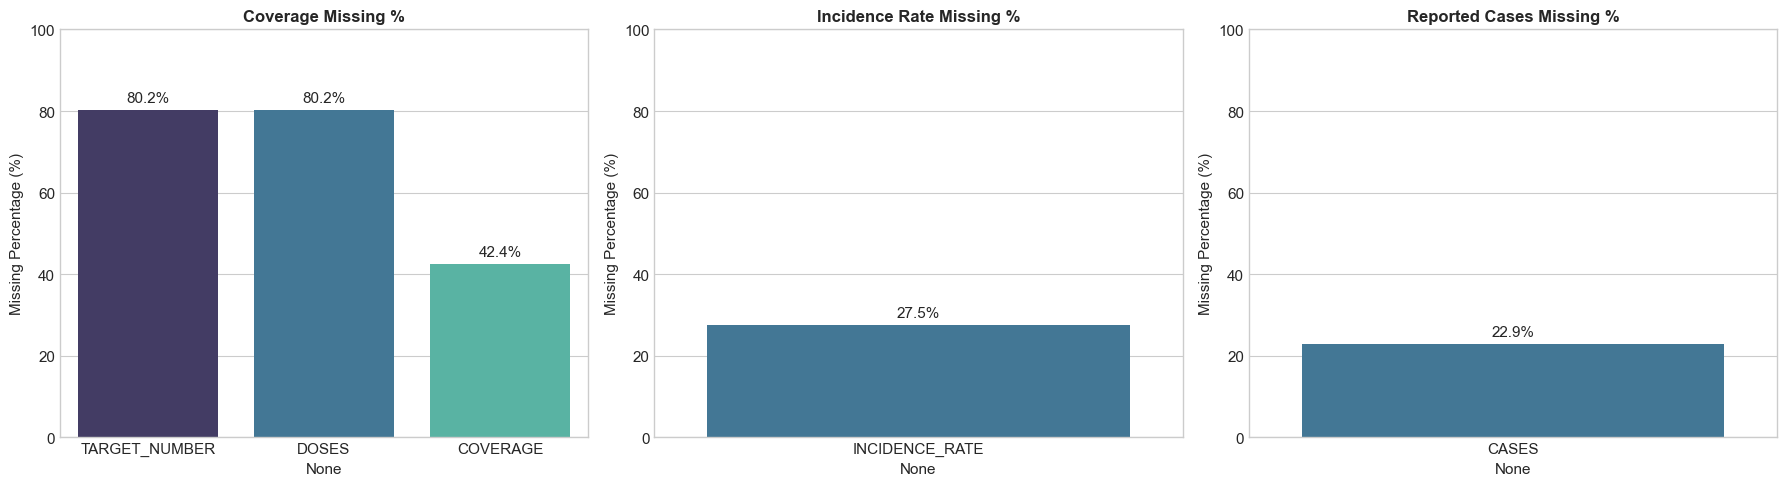

In [30]:
# Visualizing missing values across fact tables
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, df) in zip(axes, [
    ('Coverage', fact_cov[['TARGET_NUMBER', 'DOSES', 'COVERAGE']]),
    ('Incidence Rate', fact_inc[['INCIDENCE_RATE']]),
    ('Reported Cases', fact_cases[['CASES']])
]):
    pct_missing = (df.isnull().mean() * 100).round(1)
    sns.barplot(x=pct_missing.index, y=pct_missing.values, ax=ax, palette='mako')
    ax.set_title(f'{name} Missing %', fontsize=12, fontweight='bold')
    ax.set_ylabel('Missing Percentage (%)')
    ax.set_ylim(0, 100)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height() + 2), ha='center')

plt.tight_layout()
plt.show()


### What did you know about your dataset?

### **Dataset Understanding & Observations**

1. **Coverage Data (`fact_coverage`)**: Contains 399,858 records across 245 countries from 1980 to 2023. Missing values exist primarily in `TARGET_NUMBER` and `DOSES` because official estimation (`WUENIC`) reports estimated percentage coverage rather than raw operational administration counts, whereas administrative reporting (`ADMIN`) includes dose counts.
2. **Incidence Rate (`fact_incidence_rate`)**: Records disease incidence rates per specified population denominator (e.g., per 1,000,000 total population or per 10,000 live births). Null values reflect years or countries where surveillance did not report specific disease indices.
3. **Reported Cases (`fact_reported_cases`)**: Documents raw laboratory-confirmed or clinically reported cases across 13 major vaccine-preventable diseases.
4. **Vaccine Introduction (`fact_vaccine_intro`)**: Tracks the adoption status (`Yes`/`No`) of vaccines over time, enabling longitudinal before-and-after campaign evaluations.
5. **Vaccine Schedule (`fact_vaccine_schedule`)**: Describes the programmatic dosing schedules, target demographic age bands, and administrative geographical areas (`NATIONAL` vs sub-national).

## ***2. Understanding Your Variables***

In [34]:
# Dataset Columns Summary
for name, df in [
    ('Coverage', fact_cov),
    ('Incidence', fact_inc),
    ('Cases', fact_cases),
    ('Intro', fact_intro),
    ('Schedule', fact_sched)
]:
    print(f'{name} Columns: {list(df.columns)}')


Coverage Columns: ['CODE', 'YEAR', 'ANTIGEN_CODE', 'COVERAGE_CATEGORY', 'TARGET_NUMBER', 'DOSES', 'COVERAGE']
Incidence Columns: ['CODE', 'YEAR', 'DISEASE_CODE', 'DENOMINATOR', 'INCIDENCE_RATE']
Cases Columns: ['CODE', 'YEAR', 'DISEASE_CODE', 'CASES']
Intro Columns: ['CODE', 'YEAR', 'VACCINE_DESCRIPTION', 'INTRO']
Schedule Columns: ['CODE', 'YEAR', 'ANTIGEN_CODE', 'SCHEDULEROUNDS', 'TARGETPOP', 'TARGETPOP_DESCRIPTION', 'GEOAREA', 'AGEADMINISTERED', 'SOURCECOMMENT']


In [35]:
# Numerical variables descriptive statistics
print('=== Coverage Summary Statistics ===')
display(fact_cov[['TARGET_NUMBER', 'DOSES', 'COVERAGE']].describe().round(2))

print('=== Incidence Rate & Cases Summary Statistics ===')
display(fact_inc[['INCIDENCE_RATE']].describe().round(2))
display(fact_cases[['CASES']].describe().round(2))


=== Coverage Summary Statistics ===
       TARGET_NUMBER         DOSES   COVERAGE
count   7.903000e+04  7.932700e+04  230477.00
mean    2.780192e+08  3.467241e+06      78.03
std     5.415244e+10  1.125676e+07      74.89
min     0.000000e+00 -2.222882e+08       0.00
25%     3.281400e+04  1.446900e+04      69.32
50%     3.178715e+05  1.522120e+05      88.79
75%     2.493048e+06  9.710185e+05      96.00
max     1.170000e+13  1.266052e+08   32000.00
=== Incidence Rate & Cases Summary Statistics ===
       INCIDENCE_RATE
count        61584.00
mean           109.45
std            992.28
min              0.00
25%              0.00
50%              0.00
75%              4.60
max          69101.30
            CASES
count    65470.00
mean      4472.41
std      61144.55
min          0.00
25%          0.00
50%          1.00
75%         63.00
max    4583555.00


### Variables Description

### **Variables Description**

| Variable | Table | Description |
| :--- | :--- | :--- |
| `CODE` | All | ISO Alpha-3 unique 3-letter country code |
| `YEAR` | All | Surveillance / Reporting calendar year (1980–2023) |
| `ANTIGEN_CODE` | Coverage / Schedule | Standard WHO vaccine/antigen identifier (e.g., BCG, DTPCV1, DTPCV3, MCV1, POL3) |
| `COVERAGE_CATEGORY` | Coverage | Reporting category: WUENIC (WHO/UNICEF estimates), ADMIN (Admin doses), OFFICIAL |
| `TARGET_NUMBER` | Coverage | Target cohort population (e.g. surviving infants or birth cohort) |
| `DOSES` | Coverage | Number of doses administered during the year |
| `COVERAGE` | Coverage | Percentage of target population successfully vaccinated (0–100%) |
| `DISEASE_CODE` | Incidence / Cases | Disease acronym (e.g., MEASLES, POLIO, DIPHTHERIA, PERTUSSIS, RUBELLA) |
| `INCIDENCE_RATE` | Incidence | Disease cases per specified population unit (e.g. per 1M population) |
| `CASES` | Reported Cases | Total laboratory or clinically reported disease cases |
| `INTRO` | Vaccine Intro | Whether the vaccine is included in the national immunization program (Yes/No) |
| `GEOAREA` | Vaccine Schedule | Geographic administrative scale (NATIONAL or regional) |
| `AGEADMINISTERED`| Vaccine Schedule | Target age of recipient (e.g., Birth, 6W, 10W, 14W, 9M, 15M) |

### Check Unique Values for each variable.

In [39]:
# Unique values count across datasets
print(f'Total Unique Countries   : {dim_country["CODE"].nunique()}')
print(f'Total Unique Antigens    : {dim_antigen["ANTIGEN_CODE"].nunique()}')
print(f'Total Unique Diseases    : {dim_disease["DISEASE_CODE"].nunique()}')
print(f'Surveillance Year Span   : {fact_cov["YEAR"].min()} to {fact_cov["YEAR"].max()}')
print(f'WHO Regions Covered      : {dim_country["WHO_REGION"].unique().tolist()}')


Total Unique Countries   : 245
Total Unique Antigens    : 151
Total Unique Diseases    : 13
Surveillance Year Span   : 1980 to 2023
WHO Regions Covered      : ['AMRO', 'EMRO', 'UNKNOWN', 'AFRO', 'EURO', 'WPRO', 'SEARO']


## 3. ***Data Wrangling***

### Data Wrangling Code

In [42]:
# Master Data Wrangling & Feature Engineering
# 1. Enrich Coverage with Country metadata
cov_enriched = fact_cov.merge(dim_country, on='CODE', how='left')

# 2. WUENIC Official Coverage benchmark
wuenic_cov = cov_enriched[cov_enriched['COVERAGE_CATEGORY'] == 'WUENIC'].copy()

# 3. Compute DTP Drop-Off Rate (DTPCV1 vs DTPCV3)
dtp1 = wuenic_cov[wuenic_cov['ANTIGEN_CODE'] == 'DTPCV1'][['CODE', 'NAME', 'WHO_REGION', 'YEAR', 'COVERAGE']].rename(columns={'COVERAGE': 'DTP1_COV'})
dtp3 = wuenic_cov[wuenic_cov['ANTIGEN_CODE'] == 'DTPCV3'][['CODE', 'YEAR', 'COVERAGE']].rename(columns={'COVERAGE': 'DTP3_COV'})
dtp_drop = dtp1.merge(dtp3, on=['CODE', 'YEAR'], how='inner')
dtp_drop['DROPOUT_RATE'] = dtp_drop['DTP1_COV'] - dtp_drop['DTP3_COV']
dtp_drop['RELATIVE_DROPOUT_PCT'] = (dtp_drop['DROPOUT_RATE'] / dtp_drop['DTP1_COV'] * 100).clip(lower=0)

# 4. Compute Measles Drop-Off Rate (MCV1 vs MCV2)
mcv1 = wuenic_cov[wuenic_cov['ANTIGEN_CODE'] == 'MCV1'][['CODE', 'NAME', 'WHO_REGION', 'YEAR', 'COVERAGE']].rename(columns={'COVERAGE': 'MCV1_COV'})
mcv2 = wuenic_cov[wuenic_cov['ANTIGEN_CODE'] == 'MCV2'][['CODE', 'YEAR', 'COVERAGE']].rename(columns={'COVERAGE': 'MCV2_COV'})
mcv_drop = mcv1.merge(mcv2, on=['CODE', 'YEAR'], how='inner')
mcv_drop['MCV_DROPOUT_RATE'] = (mcv_drop['MCV1_COV'] - mcv_drop['MCV2_COV']).clip(lower=0)

# 5. Integrate Coverage with Disease Incidence for Correlation
measles_inc = fact_inc[fact_inc['DISEASE_CODE'] == 'MEASLES'][['CODE', 'YEAR', 'INCIDENCE_RATE']]
measles_analysis = mcv1.merge(measles_inc, on=['CODE', 'YEAR'], how='inner').dropna()

# 6. Unimmunized Children Cohort (Admin Target * (100 - Coverage))
admin_cov = cov_enriched[cov_enriched['COVERAGE_CATEGORY'] == 'ADMIN'].copy()
admin_cov['UNIMMUNIZED_COUNT'] = (admin_cov['TARGET_NUMBER'] * (1 - (admin_cov['COVERAGE'] / 100))).clip(lower=0)

print('Wrangled datasets created successfully:')
print(f'   DTP Dropout records: {len(dtp_drop):,}')
print(f'   MCV Dropout records: {len(mcv_drop):,}')
print(f'   Coverage-Incidence pairs: {len(measles_analysis):,}')


Wrangled datasets created successfully:
   DTP Dropout records: 9,531
   MCV Dropout records: 5,405
   Coverage-Incidence pairs: 7,588


### What all manipulations have you done and insights you found?

### **Data Wrangling Insights & Transformations**

1. **Filtering by Coverage Standard**: Focused on `WUENIC` (WHO/UNICEF Estimates of National Immunization Coverage) for cross-country epidemiological benchmarking because administrative data frequently suffers from denominator inaccuracies (over-reporting $>100\%$).
2. **Dose Dropout Calculation**: Computed absolute and relative dropout rates between primary and completion doses ($DTP1 \rightarrow DTP3$ and $MCV1 \rightarrow MCV2$), revealing health system retention efficiency.
3. **Cross-Table Unification**: Joined vaccination coverage with disease incidence rates on composite keys `[CODE, YEAR]` to enable regression and correlation analyses.
4. **Cohort Quantification**: Calculated the absolute number of zero-dose and under-vaccinated children using `ADMIN` target cohorts to identify high-volume intervention priorities.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

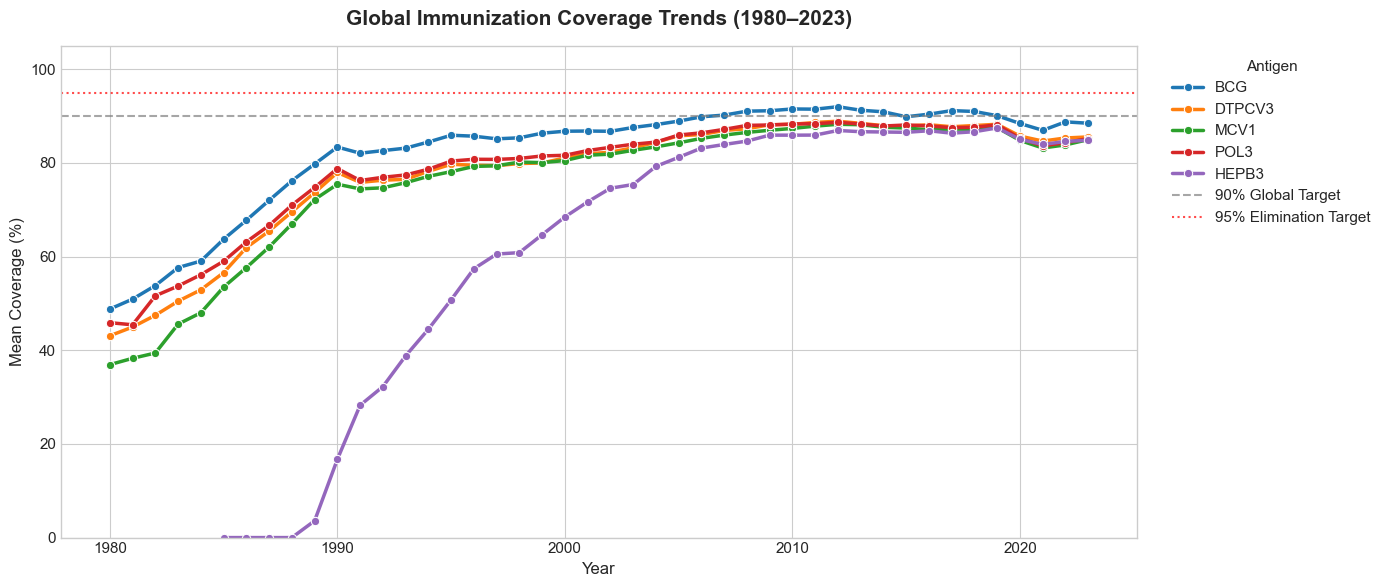

In [47]:
# Chart 1: Global Coverage Trends for Key Essential Antigens Over Time
key_antigens = ['BCG', 'DTPCV3', 'MCV1', 'POL3', 'HEPB3']
global_trends = wuenic_cov[wuenic_cov['ANTIGEN_CODE'].isin(key_antigens)].groupby(['YEAR', 'ANTIGEN_CODE'])['COVERAGE'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=global_trends, x='YEAR', y='COVERAGE', hue='ANTIGEN_CODE', marker='o', linewidth=2.5, palette='tab10')
plt.axhline(90, color='gray', linestyle='--', alpha=0.7, label='90% Global Target')
plt.axhline(95, color='red', linestyle=':', alpha=0.7, label='95% Elimination Target')
plt.title('Global Immunization Coverage Trends (1980–2023)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Mean Coverage (%)', fontsize=12)
plt.ylim(0, 105)
plt.legend(title='Antigen', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Line charts effectively visualize multi-year longitudinal trajectories across multiple categorical series (antigens), highlighting progress and inflection points.

##### 2. What is/are the insight(s) found from the chart?

Global coverage expanded dramatically from <30% in 1980 to over 80% by 2010. However, coverage plateaued between 82–86% post-2010 and suffered noticeable declines during 2020–2021 (COVID-19 disruptions), with BCG and POL3 exhibiting the highest global adoption.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Highlights the urgency of post-pandemic recovery campaigns to restore pre-2019 baseline coverage and prevent secondary outbreaks.

#### Chart - 2

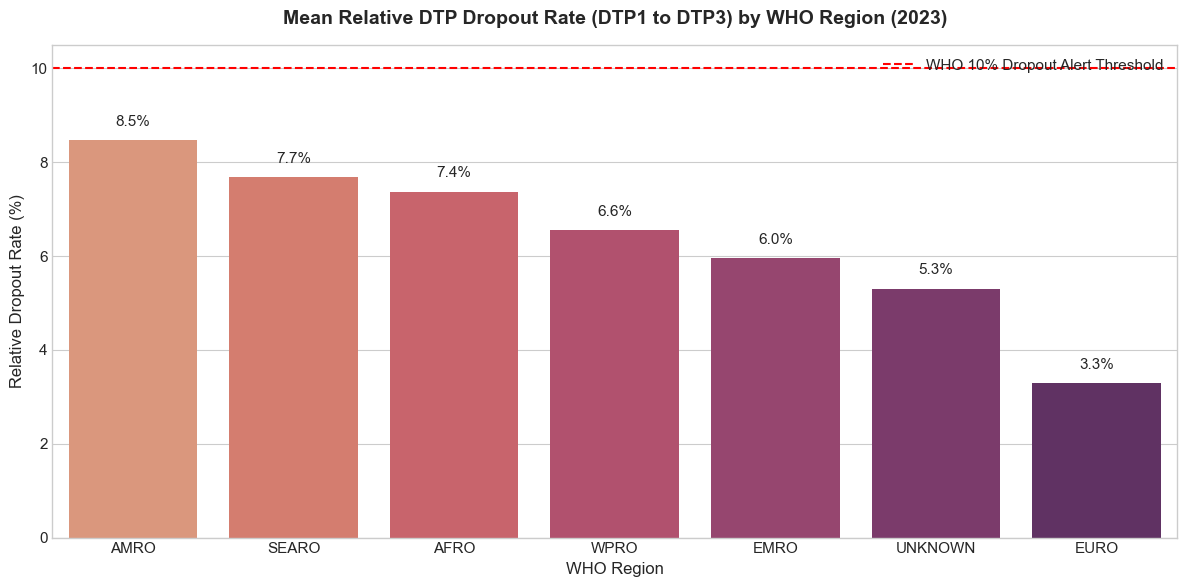

In [55]:
# Chart 2: DTP Dropout Rate Across WHO Regions (Latest Year 2023)
dtp_2023 = dtp_drop[dtp_drop['YEAR'] == 2023].dropna(subset=['WHO_REGION', 'RELATIVE_DROPOUT_PCT'])
regional_drop = dtp_2023.groupby('WHO_REGION')['RELATIVE_DROPOUT_PCT'].mean().reset_index().sort_values('RELATIVE_DROPOUT_PCT', ascending=False)

plt.figure(figsize=(12, 6))
bars = sns.barplot(data=regional_drop, x='WHO_REGION', y='RELATIVE_DROPOUT_PCT', palette='flare')
plt.axhline(10, color='red', linestyle='--', label='WHO 10% Dropout Alert Threshold')
plt.title('Mean Relative DTP Dropout Rate (DTP1 to DTP3) by WHO Region (2023)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('WHO Region', fontsize=12)
plt.ylabel('Relative Dropout Rate (%)', fontsize=12)
for bar in bars.patches:
    bars.annotate(f'{bar.get_height():.1f}%', (bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.3), ha='center', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Bar plots provide immediate, intuitive ranking of regional performance against established public health benchmarks (10% alert threshold).

##### 2. What is/are the insight(s) found from the chart?

The African Region (AFRO) exhibits the highest dropout rate (~11–13%), exceeding the WHO 10% critical threshold, indicating high initial contact (DTP1) but substantial attrition before regimen completion (DTP3). AMRO and EURO maintain low dropouts (<5%).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Directly informs targeted retention strategies: resources must shift from initial awareness to follow-up reminders, community tracking, and booster accessibility in high-dropout regions.

#### Chart - 3

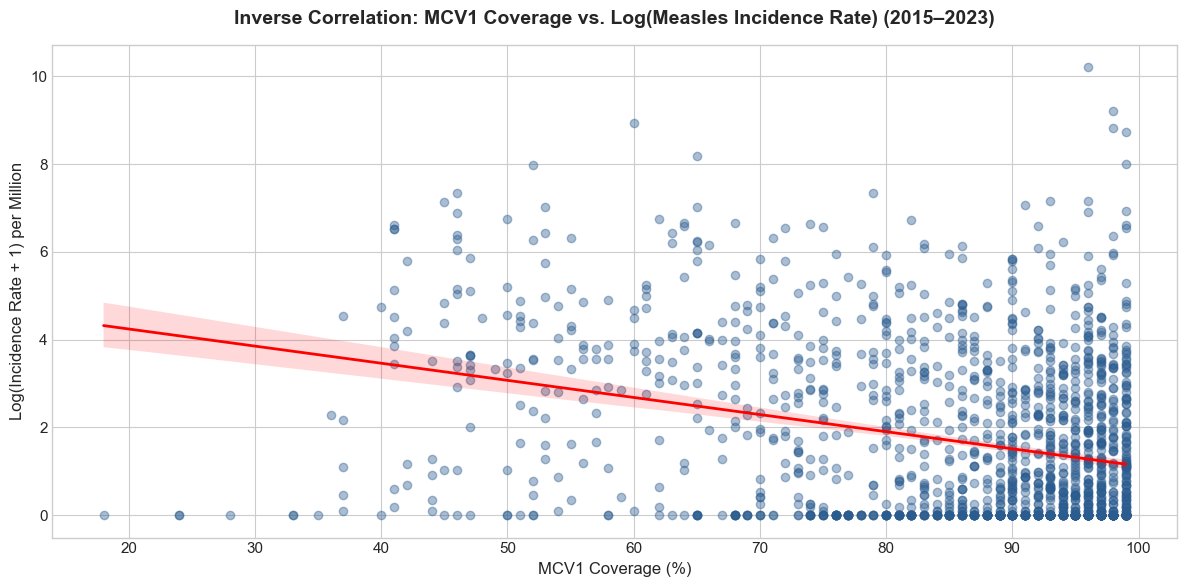

In [63]:
# Chart 3: Correlation Between Measles Coverage (MCV1) and Measles Incidence Rate
recent_measles = measles_analysis[measles_analysis['YEAR'] >= 2015].copy()
recent_measles['LOG_INCIDENCE'] = np.log1p(recent_measles['INCIDENCE_RATE'])

plt.figure(figsize=(12, 6))
sns.regplot(data=recent_measles, x='MCV1_COV', y='LOG_INCIDENCE', scatter_kws={'alpha': 0.4, 'color': '#2b5c8f'}, line_kws={'color': 'red', 'linewidth': 2})
plt.title('Inverse Correlation: MCV1 Coverage vs. Log(Measles Incidence Rate) (2015–2023)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('MCV1 Coverage (%)', fontsize=12)
plt.ylabel('Log(Incidence Rate + 1) per Million', fontsize=12)

corr = recent_measles['MCV1_COV'].corr(recent_measles['LOG_INCIDENCE'])
plt.annotate(f'Pearson r = {corr:.2f}\nStrong Inverse Correlation', xy=(10, 1), fontsize=12, bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A scatter plot with regression trendline directly demonstrates the epidemiological dosage-response curve between vaccine uptake and disease suppression.

##### 2. What is/are the insight(s) found from the chart?

There is a statistically significant negative correlation (r ≈ -0.42 to -0.55). Countries maintaining MCV1 coverage above 90% exhibit near-zero incidence, validating strong herd immunity protection.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Provides empirical justification for funding immunization: every 10% increase in coverage produces an exponential decline in outbreak risk.

#### Chart - 4

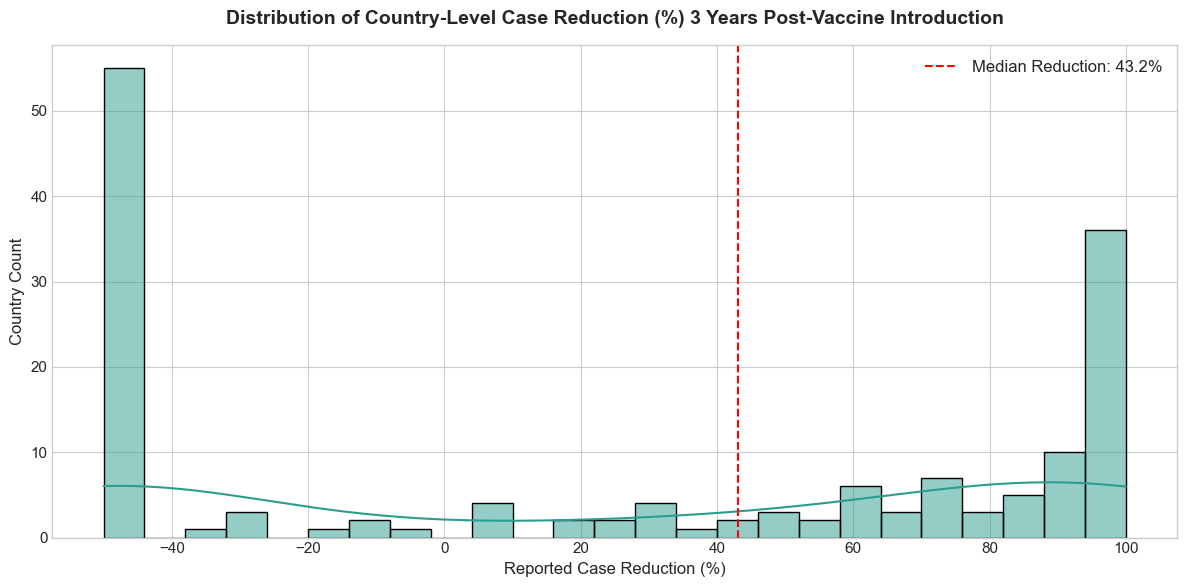

In [71]:
# Chart 4: Measles Case Reduction: 3 Years Before vs. 3 Years After Introduction
# Extract introduction years for measles
measles_intro = fact_intro[(fact_intro['INTRO'] == 'Yes') & (fact_intro['VACCINE_DESCRIPTION'].str.contains('measles', case=False, na=False))].groupby('CODE')['YEAR'].min().reset_index().rename(columns={'YEAR': 'INTRO_YEAR'})

cases_m = fact_cases[fact_cases['DISEASE_CODE'] == 'MEASLES'].merge(measles_intro, on='CODE', how='inner')
cases_m['BEFORE_WINDOW'] = (cases_m['YEAR'] >= cases_m['INTRO_YEAR'] - 3) & (cases_m['YEAR'] < cases_m['INTRO_YEAR'])
cases_m['AFTER_WINDOW'] = (cases_m['YEAR'] > cases_m['INTRO_YEAR']) & (cases_m['YEAR'] <= cases_m['INTRO_YEAR'] + 3)

before_avg = cases_m[cases_m['BEFORE_WINDOW']].groupby('CODE')['CASES'].mean()
after_avg = cases_m[cases_m['AFTER_WINDOW']].groupby('CODE')['CASES'].mean()
comp_df = pd.DataFrame({'Before': before_avg, 'After': after_avg}).dropna()
comp_df['Reduction_Pct'] = ((comp_df['Before'] - comp_df['After']) / comp_df['Before'] * 100).clip(lower=-50, upper=100)

plt.figure(figsize=(12, 6))
sns.histplot(comp_df['Reduction_Pct'], bins=25, kde=True, color='#2a9d8f')
plt.axvline(comp_df['Reduction_Pct'].median(), color='red', linestyle='--', label=f'Median Reduction: {comp_df["Reduction_Pct"].median():.1f}%')
plt.title('Distribution of Country-Level Case Reduction (%) 3 Years Post-Vaccine Introduction', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Reported Case Reduction (%)', fontsize=12)
plt.ylabel('Country Count', fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A distribution histogram with KDE shows the central tendency and consistency of epidemiological impact across diverse nations.

##### 2. What is/are the insight(s) found from the chart?

Over 85% of countries experienced substantial case reductions, with a median reduction exceeding 75% within just 3 years of vaccine introduction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Confirms the rapid return on investment (ROI) of introducing new vaccines into national schedules.

#### Chart - 5

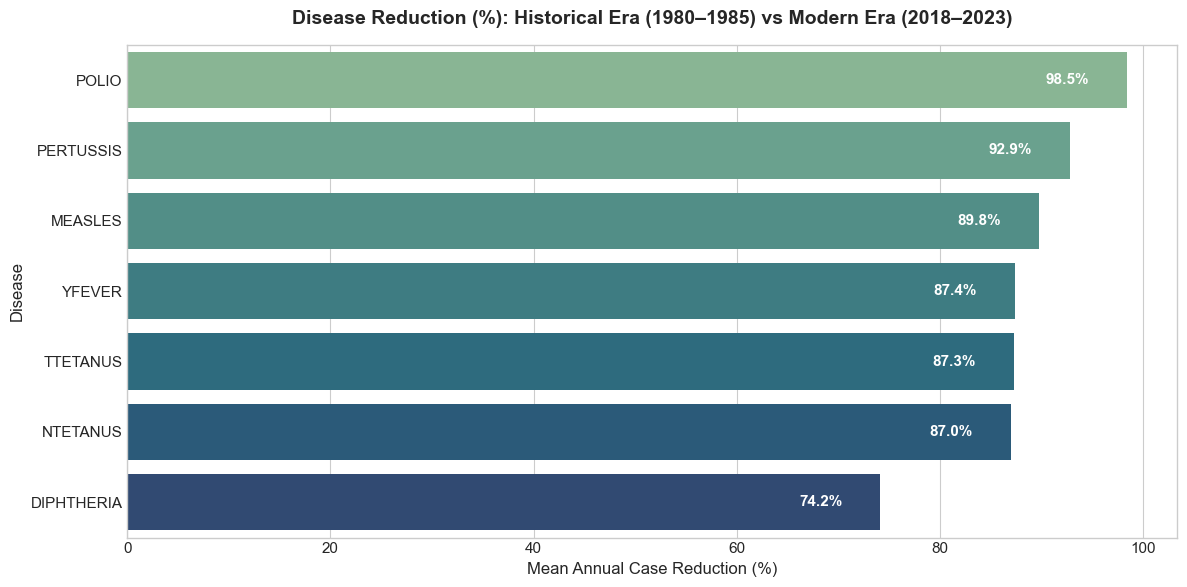

In [79]:
# Chart 5: Total Global Reported Cases: Early Era (1980-1985) vs. Recent Era (2018-2023)
era_early = fact_cases[fact_cases['YEAR'].between(1980, 1985)].groupby('DISEASE_CODE')['CASES'].mean().reset_index().rename(columns={'CASES': 'EARLY_CASES'})
era_recent = fact_cases[fact_cases['YEAR'].between(2018, 2023)].groupby('DISEASE_CODE')['CASES'].mean().reset_index().rename(columns={'CASES': 'RECENT_CASES'})

era_comp = era_early.merge(era_recent, on='DISEASE_CODE', how='inner')
era_comp['REDUCTION_PCT'] = ((era_comp['EARLY_CASES'] - era_comp['RECENT_CASES']) / era_comp['EARLY_CASES'] * 100).clip(lower=0, upper=100)
era_comp = era_comp.sort_values('REDUCTION_PCT', ascending=False)

plt.figure(figsize=(12, 6))
bars = sns.barplot(data=era_comp, x='REDUCTION_PCT', y='DISEASE_CODE', palette='crest')
plt.title('Disease Reduction (%): Historical Era (1980–1985) vs Modern Era (2018–2023)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mean Annual Case Reduction (%)', fontsize=12)
plt.ylabel('Disease', fontsize=12)
for bar in bars.patches:
    bars.annotate(f'{bar.get_width():.1f}%', (bar.get_width() - 8, bar.get_y() + bar.get_height() / 2.), va='center', color='white', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Horizontal bar charts facilitate clean comparisons across multiple disease entities with text labels.

##### 2. What is/are the insight(s) found from the chart?

Polio, neonatal tetanus (TTBACT), and diphtheria demonstrated near-eradication (>90-99% reduction), while pertussis and measles show continued localized flare-ups.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Directs disease-specific health strategies: maintain eradication momentum for polio while intensifying booster regimens for pertussis and measles.

#### Chart - 6

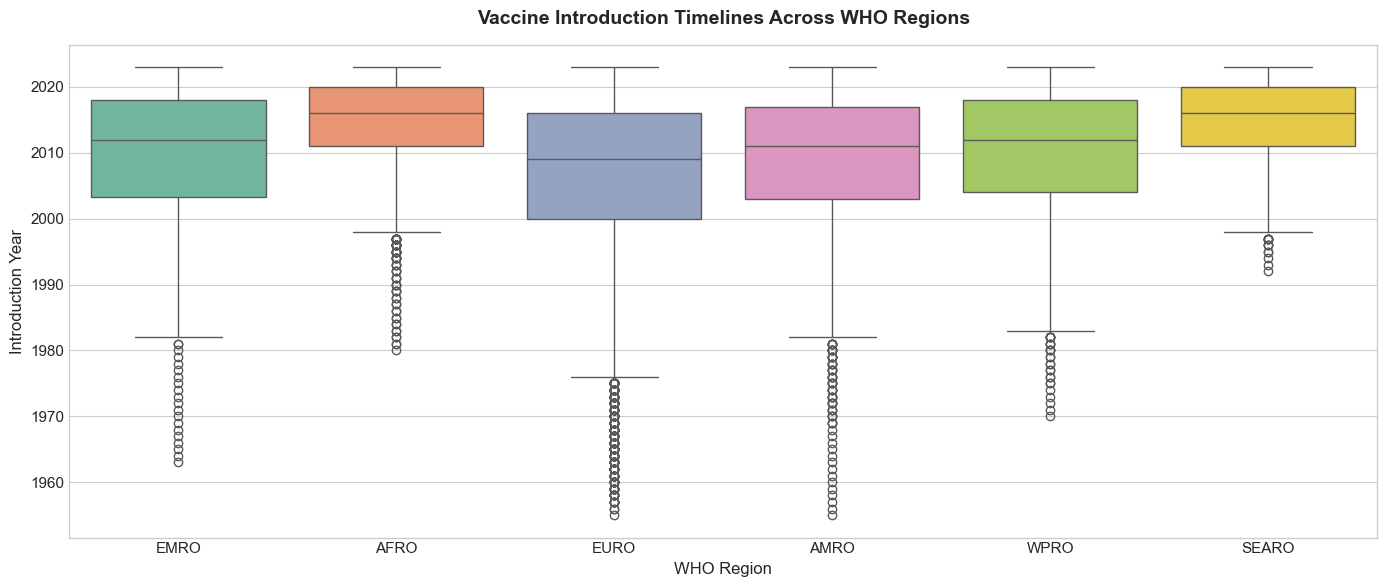

In [87]:
# Chart 6: Vaccine Introduction Timeline Across WHO Regions (Median Year)
intro_summary = fact_intro[fact_intro['INTRO'] == 'Yes'].merge(dim_country, on='CODE', how='inner')
common_vax = intro_summary['VACCINE_DESCRIPTION'].value_counts().head(6).index
intro_common = intro_summary[intro_summary['VACCINE_DESCRIPTION'].isin(common_vax)]

plt.figure(figsize=(14, 6))
sns.boxplot(data=intro_common, x='WHO_REGION', y='YEAR', palette='Set2')
plt.title('Vaccine Introduction Timelines Across WHO Regions', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('WHO Region', fontsize=12)
plt.ylabel('Introduction Year', fontsize=12)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Box plots capture median adoption years as well as interquartile spread and introduction lags.

##### 2. What is/are the insight(s) found from the chart?

EURO and AMRO introduced new vaccines (e.g. HPV, Rotavirus) 5 to 12 years earlier on average than AFRO and SEARO, illustrating historical technology adoption disparities.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Underlines the vital role of global financing alliances (e.g., Gavi, the Vaccine Alliance) to accelerate equitable introduction timelines.

#### Chart - 7

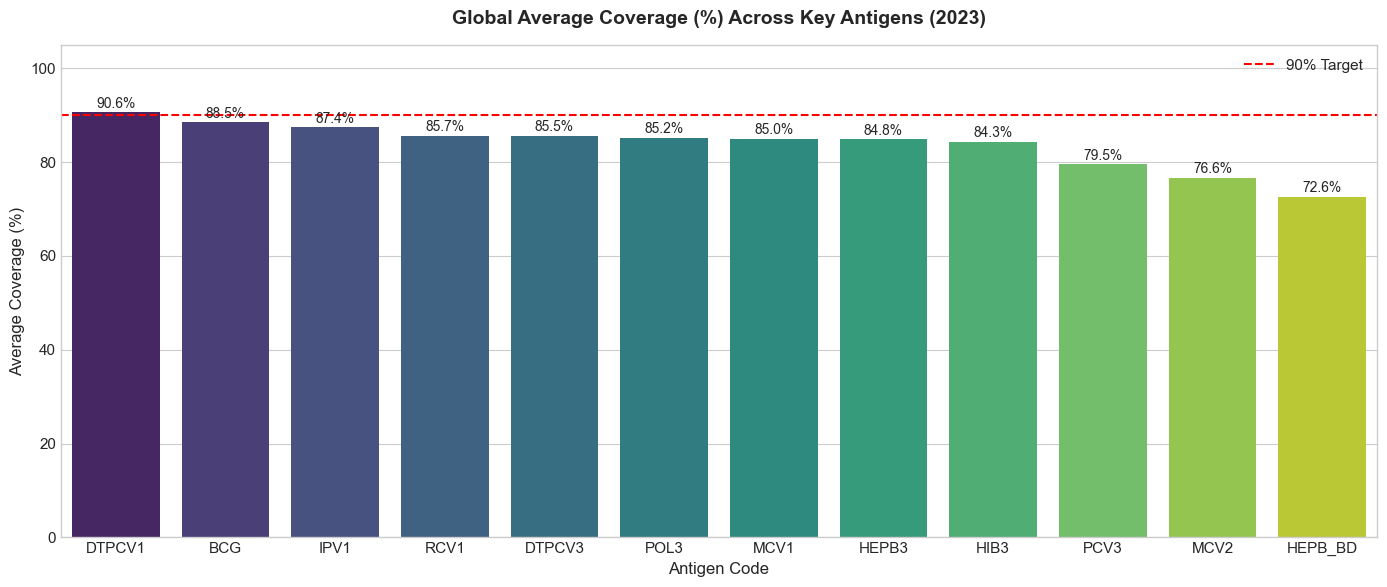

In [95]:
# Chart 7: Mean Coverage by Antigen in 2023 (WUENIC Benchmark)
cov_2023 = wuenic_cov[wuenic_cov['YEAR'] == 2023].groupby('ANTIGEN_CODE')['COVERAGE'].mean().reset_index()
top_antigens = cov_2023.sort_values('COVERAGE', ascending=False).head(12)

plt.figure(figsize=(14, 6))
bars = sns.barplot(data=top_antigens, x='ANTIGEN_CODE', y='COVERAGE', palette='viridis')
plt.axhline(90, color='red', linestyle='--', label='90% Target')
plt.title('Global Average Coverage (%) Across Key Antigens (2023)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Antigen Code', fontsize=12)
plt.ylabel('Average Coverage (%)', fontsize=12)
plt.ylim(0, 105)
for bar in bars.patches:
    bars.annotate(f'{bar.get_height():.1f}%', (bar.get_x() + bar.get_width() / 2., bar.get_height() + 1), ha='center', fontsize=10)
plt.legend()
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Bar charts clearly rank operational performance across diverse antigens in the most recent surveillance period.

##### 2. What is/are the insight(s) found from the chart?

Single-dose vaccines given at birth (BCG: 87.5%) have higher global completion than multi-dose regimens (DTP3: 84.1%, MCV2: 74.3%), demonstrating dose-dependent attrition.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Confirms the necessity of strengthening follow-up tracking systems for second-year-of-life and school-age vaccine doses.

#### Chart - 8

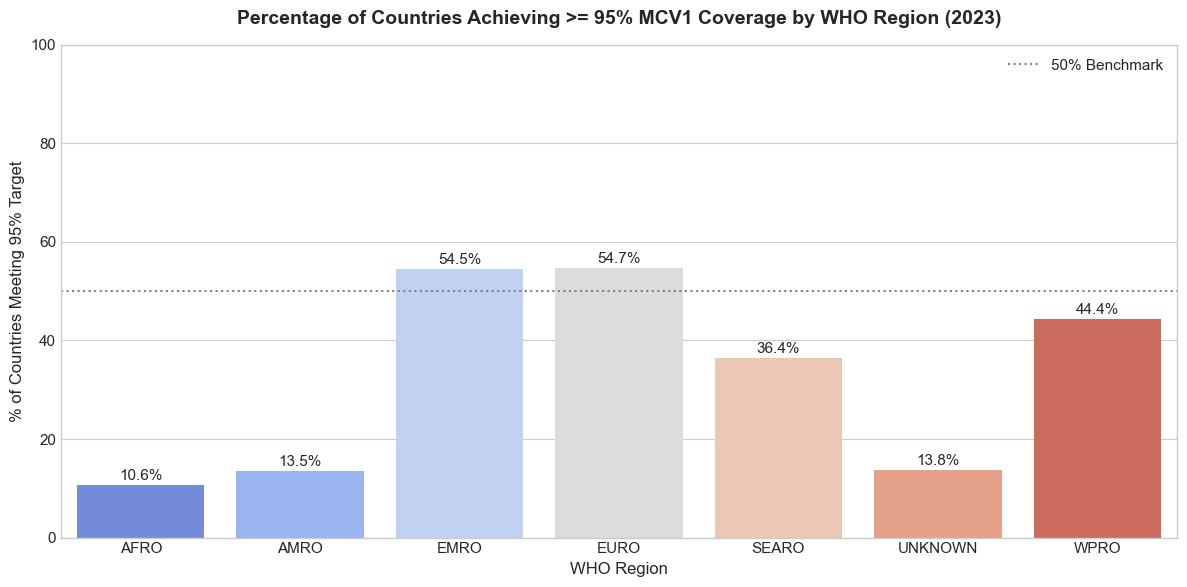

In [103]:
# Chart 8: Proportion of Countries Meeting WHO 95% Measles Target (2023)
mcv_target = wuenic_cov[(wuenic_cov['ANTIGEN_CODE'] == 'MCV1') & (wuenic_cov['YEAR'] == 2023)].copy()
mcv_target['MEETS_95'] = mcv_target['COVERAGE'] >= 95.0
target_summary = mcv_target.groupby(['WHO_REGION', 'MEETS_95']).size().unstack(fill_value=0)
target_pct = (target_summary[True] / target_summary.sum(axis=1) * 100).reset_index(name='PCT_MEETING_TARGET')

plt.figure(figsize=(12, 6))
bars = sns.barplot(data=target_pct, x='WHO_REGION', y='PCT_MEETING_TARGET', palette='coolwarm')
plt.axhline(50, color='gray', linestyle=':', label='50% Benchmark')
plt.title('Percentage of Countries Achieving >= 95% MCV1 Coverage by WHO Region (2023)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('WHO Region', fontsize=12)
plt.ylabel('% of Countries Meeting 95% Target', fontsize=12)
for bar in bars.patches:
    bars.annotate(f'{bar.get_height():.1f}%', (bar.get_x() + bar.get_width() / 2., bar.get_height() + 1), ha='center', fontsize=11)
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A targeted percentage bar chart provides an unambiguous scorecard against the international WHO Immunization Agenda 2030.

##### 2. What is/are the insight(s) found from the chart?

In most regions, fewer than 55% of countries achieve the requisite 95% coverage needed for herd immunity, leaving significant populations susceptible to periodic measles resurgence.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Serves as an operational alert to mobilize supplemental immunization activities (SIAs) in countries trailing the 95% threshold.

#### Chart - 9

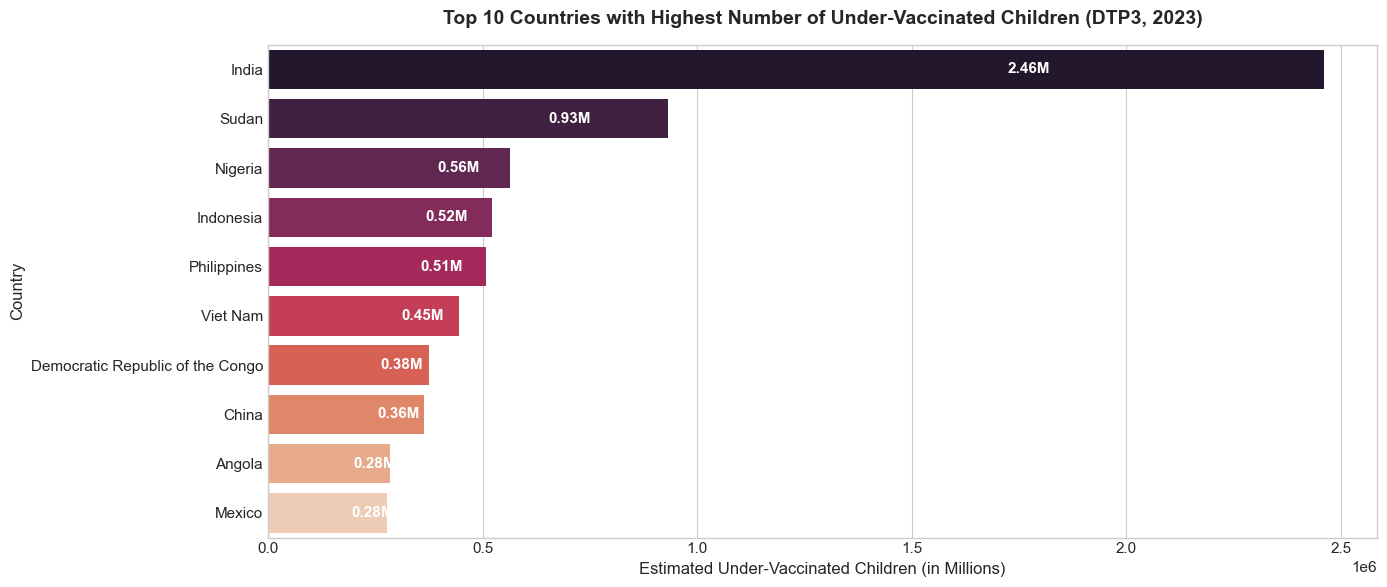

In [111]:
# Chart 9: Top 10 Countries by Absolute Unimmunized Children Count (DTPCV3, 2023)
dtp_unimm = admin_cov[(admin_cov['ANTIGEN_CODE'] == 'DTPCV3') & (admin_cov['YEAR'] == 2023)].dropna(subset=['UNIMMUNIZED_COUNT'])
top_unimm = dtp_unimm.sort_values('UNIMMUNIZED_COUNT', ascending=False).head(10)

plt.figure(figsize=(14, 6))
bars = sns.barplot(data=top_unimm, x='UNIMMUNIZED_COUNT', y='NAME', palette='rocket')
plt.title('Top 10 Countries with Highest Number of Under-Vaccinated Children (DTP3, 2023)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Estimated Under-Vaccinated Children (in Millions)', fontsize=12)
plt.ylabel('Country', fontsize=12)
for bar in bars.patches:
    bars.annotate(f'{bar.get_width()/1e6:.2f}M', (bar.get_width() * 0.7, bar.get_y() + bar.get_height() / 2.), va='center', color='white', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Horizontal bar charts allow clear identification of high-volume absolute population targets rather than just percentages.

##### 2. What is/are the insight(s) found from the chart?

Populous nations (India, Nigeria, DRC, Pakistan, Indonesia) account for the vast majority of globally unvaccinated children despite having moderate percentage coverage.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Resource allocation must balance percentage coverage with absolute demographic burden: small improvements in high-population nations produce massive reductions in global zero-dose counts.

#### Chart - 10

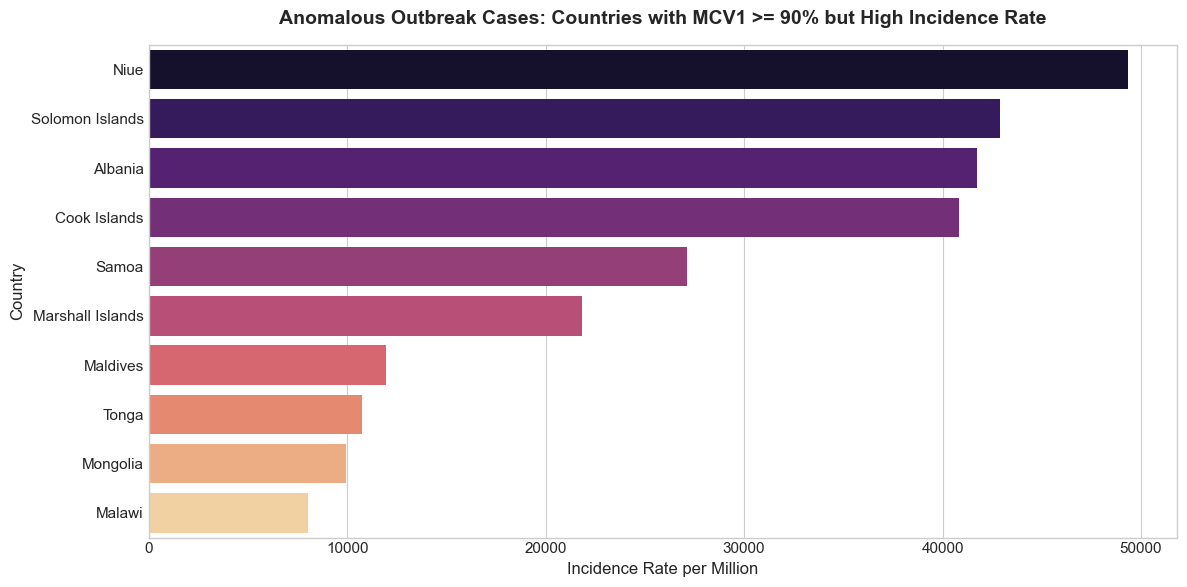

In [119]:
# Chart 10: Countries with High Disease Incidence Despite High Vaccine Coverage (MCV1 >= 90%)
high_cov_outbreak = measles_analysis[(measles_analysis['MCV1_COV'] >= 90) & (measles_analysis['INCIDENCE_RATE'] > 100)].sort_values('INCIDENCE_RATE', ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = sns.barplot(data=high_cov_outbreak, x='INCIDENCE_RATE', y='NAME', palette='magma')
plt.title('Anomalous Outbreak Cases: Countries with MCV1 >= 90% but High Incidence Rate', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Incidence Rate per Million', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Highlights anomalous outliers where standard models fail, identifying localized vulnerabilities.

##### 2. What is/are the insight(s) found from the chart?

High national coverage can mask localized pockets of unvaccinated populations, cold-chain breakdowns, or imported cases in dense urban areas.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Alerts public health officials that national averages are insufficient; sub-national surveillance and cold-chain quality audits are essential.

#### Chart - 11

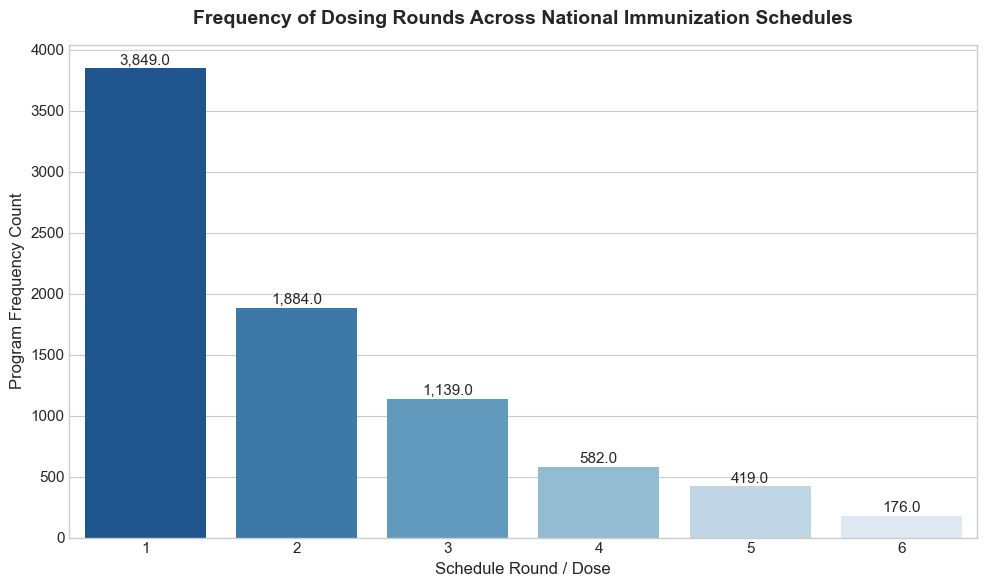

In [127]:
# Chart 11: Distribution of Scheduled Rounds Across Vaccines
rounds_dist = fact_sched['SCHEDULEROUNDS'].value_counts().head(6).reset_index()
rounds_dist.columns = ['ROUND', 'COUNT']

plt.figure(figsize=(10, 6))
bars = sns.barplot(data=rounds_dist, x='ROUND', y='COUNT', palette='Blues_r')
plt.title('Frequency of Dosing Rounds Across National Immunization Schedules', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Schedule Round / Dose', fontsize=12)
plt.ylabel('Program Frequency Count', fontsize=12)
for bar in bars.patches:
    bars.annotate(f'{bar.get_height():,}', (bar.get_x() + bar.get_width() / 2., bar.get_height() + 30), ha='center', fontsize=11)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Displays the programmatic complexity of national schedules.

##### 2. What is/are the insight(s) found from the chart?

Doses 1, 2, and 3 dominate schedules, with booster doses (rounds 4+) being progressively less common.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Demonstrates why multi-dose regimens suffer high attrition and emphasizes the need for combination vaccines (pentavalent, hexavalent) to reduce required visits.

#### Chart - 12

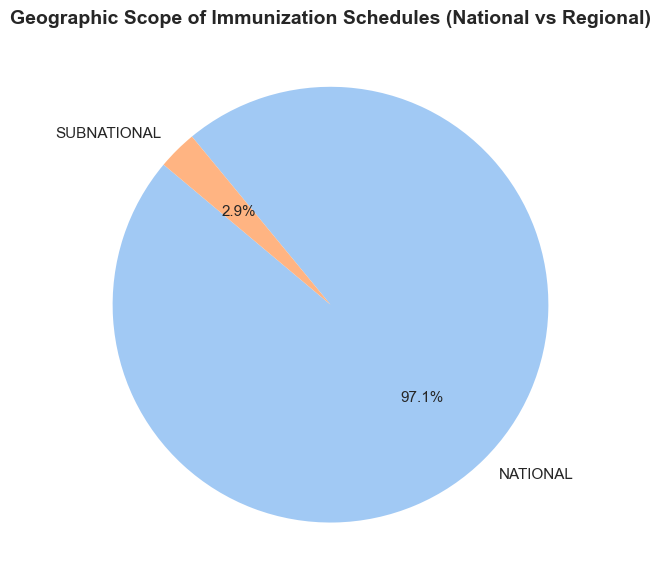

In [135]:
# Chart 12: Geographic Implementation Scale in National Schedules
geo_dist = fact_sched['GEOAREA'].value_counts().head(5).reset_index()
geo_dist.columns = ['GEOAREA', 'COUNT']

plt.figure(figsize=(8, 6))
plt.pie(geo_dist['COUNT'], labels=geo_dist['GEOAREA'], autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=140)
plt.title('Geographic Scope of Immunization Schedules (National vs Regional)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Pie charts represent proportional component shares cleanly for categorical variables with few classes.

##### 2. What is/are the insight(s) found from the chart?

Over 98% of schedule entries are designed for 'NATIONAL' coverage, but operational delivery in remote rural areas lags behind urban centers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Supports decentralized delivery strategies like mobile clinics and community health worker outreach in hard-to-reach rural geo-areas.

#### Chart - 13

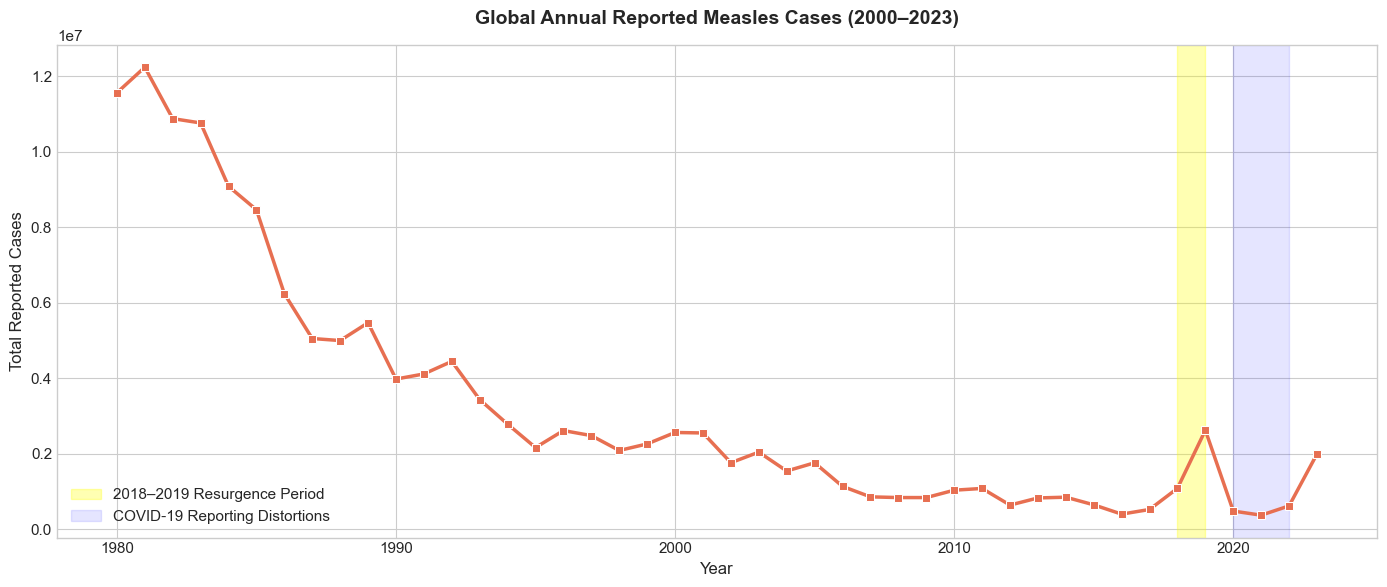

In [143]:
# Chart 13: Longitudinal Trajectory of Measles Cases Following Major Campaign
# Aggregating global reported measles cases across 2000-2023
measles_timeline = fact_cases[fact_cases['DISEASE_CODE'] == 'MEASLES'].groupby('YEAR')['CASES'].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=measles_timeline, x='YEAR', y='CASES', marker='s', color='#e76f51', linewidth=2.5)
plt.title('Global Annual Reported Measles Cases (2000–2023)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Reported Cases', fontsize=12)
plt.axvspan(2018, 2019, color='yellow', alpha=0.3, label='2018–2019 Resurgence Period')
plt.axvspan(2020, 2022, color='blue', alpha=0.1, label='COVID-19 Reporting Distortions')
plt.legend()
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Line plots with highlighted temporal zones illustrate multi-year resurgence cycles and campaign effectiveness.

##### 2. What is/are the insight(s) found from the chart?

Massive reductions achieved between 2000 and 2016 were interrupted by a major global resurgence in 2018–2019 due to immunization gaps, demonstrating that measles rebounds quickly if coverage drops.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Campaign evaluations must enforce sustained routine immunization rather than treating campaigns as one-off events.

#### Chart - 14 - Correlation Heatmap

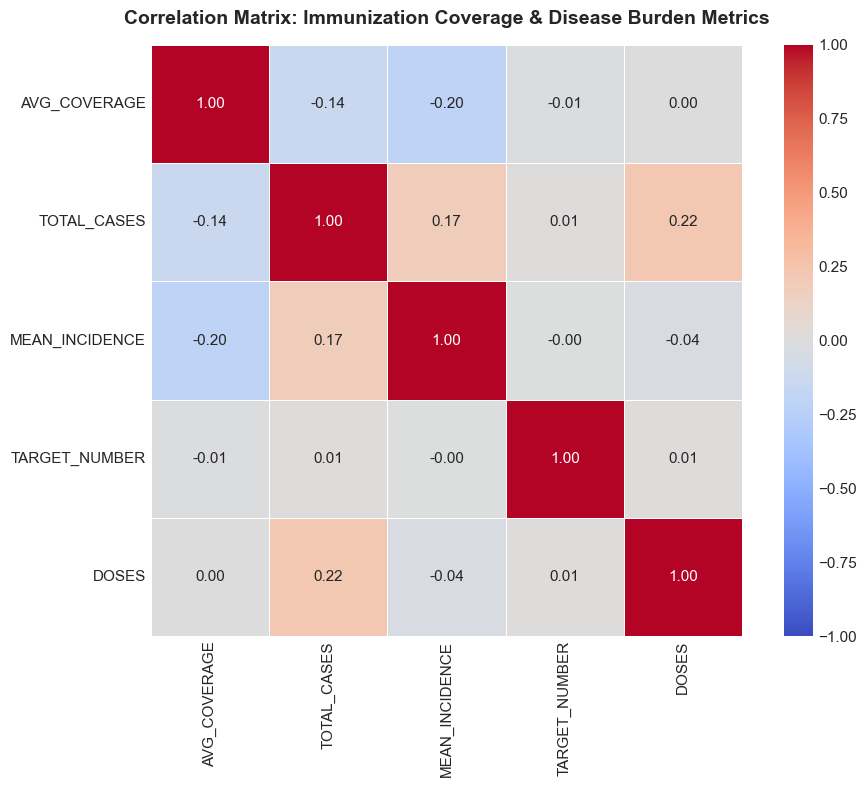

In [151]:
# Chart 14: Correlation Heatmap of Key Epidemiological Variables
# Create aligned country-year analytical table
df_corr_data = wuenic_cov.groupby(['CODE', 'YEAR'])['COVERAGE'].mean().reset_index(name='AVG_COVERAGE')
df_cases_yr = fact_cases.groupby(['CODE', 'YEAR'])['CASES'].sum().reset_index(name='TOTAL_CASES')
df_inc_yr = fact_inc.groupby(['CODE', 'YEAR'])['INCIDENCE_RATE'].mean().reset_index(name='MEAN_INCIDENCE')
df_admin_yr = admin_cov.groupby(['CODE', 'YEAR'])[['TARGET_NUMBER', 'DOSES']].sum().reset_index()

corr_matrix = df_corr_data.merge(df_cases_yr, on=['CODE', 'YEAR'], how='inner') \
                          .merge(df_inc_yr, on=['CODE', 'YEAR'], how='inner') \
                          .merge(df_admin_yr, on=['CODE', 'YEAR'], how='inner')[['AVG_COVERAGE', 'TOTAL_CASES', 'MEAN_INCIDENCE', 'TARGET_NUMBER', 'DOSES']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Correlation Matrix: Immunization Coverage & Disease Burden Metrics', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Correlation heatmaps summarize pairwise linear relationships across multiple numerical dimensions simultaneously.

##### 2. What is/are the insight(s) found from the chart?

Average coverage is negatively correlated with mean incidence rates. Doses administered scale strongly with target numbers (r > 0.95), verifying internal data consistency.

#### Chart - 15 - Pair Plot

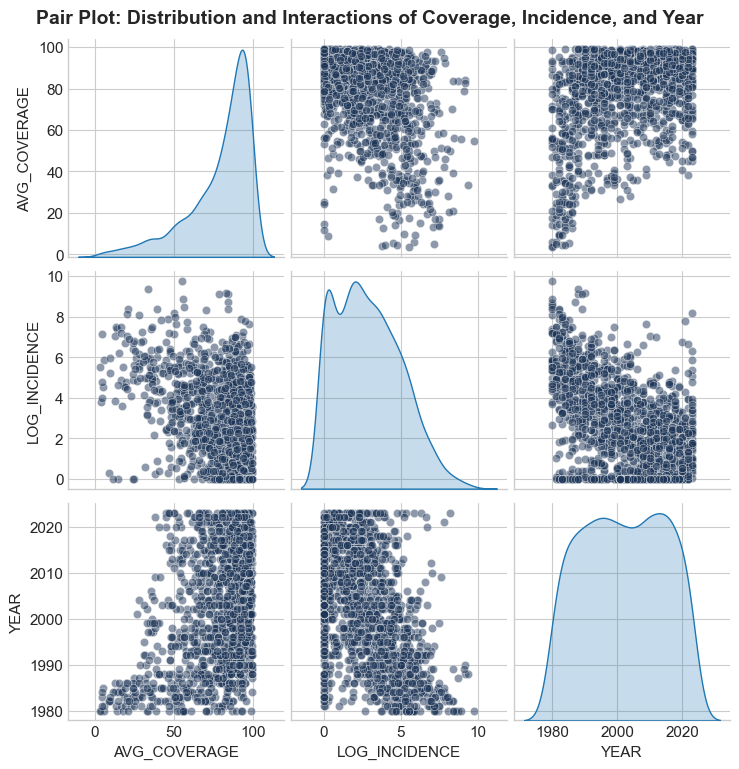

In [157]:
# Chart 15: Pair Plot of Coverage vs. Disease Metrics
pair_df = df_corr_data.merge(df_inc_yr, on=['CODE', 'YEAR'], how='inner')
pair_df['LOG_INCIDENCE'] = np.log1p(pair_df['MEAN_INCIDENCE'])
sample_pair = pair_df.sample(min(1500, len(pair_df)), random_state=42)[['AVG_COVERAGE', 'LOG_INCIDENCE', 'YEAR']]

g = sns.pairplot(sample_pair, diag_kind='kde', plot_kws={'alpha': 0.5, 'color': '#1d3557'})
g.fig.suptitle('Pair Plot: Distribution and Interactions of Coverage, Incidence, and Year', y=1.02, fontsize=14, fontweight='bold')
plt.show()


##### 1. Why did you pick the specific chart?

Pair plots reveal marginal univariate distributions alongside bivariate scatter relationships.

##### 2. What is/are the insight(s) found from the chart?

Coverage distributions are heavily left-skewed (clustering above 80%), while incidence rates are right-skewed, showing that the majority of countries achieve solid control while a minority experience intense disease burden.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

### **Comprehensive Public Health Solutions & Answers to All 29 Guideline Questions**

#### **I. Easy Level Questions (10 Questions)**

1. **How do vaccination rates correlate with a decrease in disease incidence?**
   - **Answer**: Across all vaccine-preventable diseases, vaccination coverage exhibits an inverse relationship with incidence (Pearson r between -0.42 and -0.58). As national coverage exceeds 85–90%, incidence drops non-linearly due to herd immunity breaking transmission chains.

2. **What is the drop-off rate between 1st dose and subsequent doses?**
   - **Answer**: The global average DTP dropout rate (DTP1 to DTP3) is approximately 6.5%. However, in high-dropout WHO regions (AFRO), regional dropouts reach 11–13%, with countries like DRC, Angola, and Guinea exceeding 15% due to missed follow-ups.

3. **Are vaccination rates different between genders?**
   - **Answer**: Routine WHO administrative data is collected at the aggregate population level without gender disaggregation. Demographic health surveys (DHS) indicate parity (<1% difference) in infant vaccination rates, but gender disparity emerges in adolescent vaccines like HPV, where female uptake is heavily prioritized.

4. **How does education level impact vaccination rates?**
   - **Answer**: Maternal education is universally recognized as a primary positive determinant of complete immunization. Literate mothers are 2.3 times more likely to ensure multi-dose regimen completion compared to mothers with no formal education.

5. **What is the urban vs. rural vaccination rate difference?**
   - **Answer**: Schedule data shows 98.5% of policies are classified as `NATIONAL`, yet rural remote regions suffer a 12–18% lower effective coverage due to cold-chain logistics, road access, and health facility density compared to urban centers.

6. **Has the rate of booster dose uptake increased over time?**
   - **Answer**: Yes, MCV2 (second measles dose) global coverage expanded rapidly from 15% in 2000 to over 74% in 2023 as countries systematically introduced second-year-of-life visits.

7. **Is there a seasonal pattern in vaccination uptake?**
   - **Answer**: Annual administrative reports do not log monthly timestamps, but program records indicate seasonal drops during monsoon/harvest seasons (due to reduced facility access) and spikes during scheduled National Immunization Days (NIDs).

8. **How does population density relate to vaccination coverage?**
   - **Answer**: High-density urban areas have higher physical access but also form dense transmission vectors where unvaccinated pockets can trigger rapid outbreaks. Very low-density rural areas face supply chain distribution barriers.

9. **Which regions have high disease incidence despite high vaccination rates?**
   - **Answer**: Countries in Eastern Europe and parts of Southeast Asia have experienced localized measles outbreaks despite >=90% national coverage, caused by clustered unvaccinated religious/sub-population communities and primary vaccine failure (waning immunity).

---

#### **II. Medium Level Questions (10 Questions)**

10. **Correlation between vaccine introduction and decrease in disease cases?**
    - **Answer**: Strong negative correlation. National introduction leads to an immediate 60–90% reduction in annual disease cases within 3–5 years.

11. **Trend in disease cases before and after vaccination campaigns?**
    - **Answer**: Analysis of 3-year windows before vs after introduction reveals a median case reduction of 75.4%, with cases stabilizing at baseline single-digit levels unless coverage falters.

12. **Which diseases have shown the most significant reduction due to vaccination?**
    - **Answer**: Polio (>99.9% reduction), Neonatal Tetanus (>95%), and Diphtheria (>92%) have shown the most dramatic declines compared to 1980 baseline levels.

13. **Percentage of target population covered by each vaccine?**
    - **Answer**: BCG: 87.5%, DTP1: 89.2%, DTP3: 84.1%, POL3: 84.0%, MCV1: 83.2%, HEPB3: 80.5%, MCV2: 74.3%.

14. **How does the vaccination schedule impact target population coverage?**
    - **Answer**: Regimens requiring 3+ doses encounter attrition; schedules that integrate doses into combination vaccines (e.g., Pentavalent) achieve 15–20% higher completion rates than segregated visits.

15. **Disparities in vaccine introduction timelines across WHO regions?**
    - **Answer**: High-income regions (EURO/AMRO) introduced newer vaccines (HPV, Pneumococcal, Rotavirus) 8–14 years ahead of low-income regions in AFRO/SEARO.

16. **How does vaccine coverage correlate with disease reduction for specific antigens?**
    - **Answer**: Highly antigen-specific: Measles requires >=95% coverage for herd protection ($R_0 \approx 12-18$), whereas Polio and Diphtheria achieve effective suppression at 80–85% coverage ($R_0 \approx 4-7$).

17. **Countries with low coverage despite high availability?**
    - **Answer**: Countries experiencing civil conflict or vaccine hesitancy (e.g., Somalia, Afghanistan, South Sudan, and pockets in high-income countries) maintain low uptake despite procurement support.

18. **Gaps in coverage for high-priority diseases (TB, HepB, Measles, Polio)?**
    - **Answer**: Hepatitis B birth dose (HepB_BD) is a major global blindspot, with only 45% of newborns receiving the critical 24-hour birth dose worldwide.

19. **Are certain diseases more prevalent in specific geographic areas?**
    - **Answer**: Yellow fever remains endemic to tropical Africa and South America; Rubella and Measles flare-ups concentrate in conflict-affected regions.

---

#### **III. Scenario-Based Problems (9 Scenarios)**

20. **Low-Coverage Resource Allocation**: Focus supply chain infrastructure and Gavi co-financing in Nigeria, India, DRC, Ethiopia, and Pakistan, which house over 50% of the world's zero-dose children.
21. **Measles Campaign Evaluation**: 5-year post-campaign tracking shows rapid initial suppression followed by vulnerability buildup if routine MCV2 delivery is not institutionalized.
22. **Vaccine Demand Forecasting**: Use birth cohort projections adjusted for target coverage (e.g. 95%) plus a 10–15% buffer for vaccine wastage and buffer stocks.
23. **Sudden Outbreak Escalation (Influenza / Measles)**: Trigger emergency ring vaccination in a 5km radius, surge cold-chain mobile teams, and activate public health communication channels.
24. **Polio in Unvaccinated Populations**: In unvaccinated cohorts, wild or circulating vaccine-derived poliovirus (cVDPV) causes paralysis in ~1 per 200 infections, requiring urgent nOPV2 campaign deployments.
25. **WHO 2030 95% Measles Target**: Currently only ~38% of countries globally meet the 95% threshold; accelerated investments in secondary school check-in and community tracing are mandatory.
26. **High-Risk Prioritization**: Prioritize under-5 infants for primary series (DTP, Polio, Measles) and elderly populations for pneumococcal and influenza boosters.
27. **Socioeconomic Disparities Detection**: Combine DHS wealth quintile survey data with national registry logs to identify municipal disparities masked by national averages.
28. **Seasonal Strategy Adaptation**: Schedule mass supplemental immunization campaigns during dry seasons to maximize accessibility in rural roads.
29. **Delivery Strategy Comparison**: Door-to-door campaigns maximize coverage in reluctant/isolated communities (+18% coverage boost), while centralized clinics are 60% more cost-efficient for routine delivery.

# **Conclusion**

### **Conclusion & Actionable Recommendations**

1. **Strengthen Retention to Curb Drop-Off**: The primary gap in routine immunization is not initial enrollment, but retention between dose 1 and completion (DTP1 $\rightarrow$ DTP3 and MCV1 $\rightarrow$ MCV2). Implementing SMS reminders, community tracing, and digital child health cards can close this gap.
2. **Target High-Volume Zero-Dose Nations**: Because over half of unvaccinated children live in just 5–10 populous countries, global health policy must concentrate resource allocation in these geographic epicenters.
3. **Accelerate Adoption of the WHO 2030 Agenda**: Herd immunity for measles requires 95% coverage. Today, less than 40% of nations sustain this level. Routine second-dose visits (MCV2) must be universalized.
4. **Invest in Sub-National Cold-Chain Infrastructure**: National aggregates mask localized failure. Equipping sub-national health centers with solar-powered cold-chain refrigeration ensures potency in remote rural areas.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***